# Tier 6 · Notebook 27 — Reproducing Papers, and the Grokking Phenomenon

> **Goal:** learn the **reproduce-a-paper workflow** — the single most important practical skill for a research residency — and apply it end-to-end to reproduce one of the most striking recent results: **grokking** (Power et al. 2022), where a network *suddenly* generalizes long after it has perfectly memorized the training set.

**Why reproduction is the skill.** A residency isn't about reciting papers; it's about *making them run*, checking whether their claims hold, and building on them. Reproducing a result forces you to understand every detail the paper glossed over, exposes what actually matters (vs what the authors thought mattered), and gives you a working artifact to extend. Interviewers love "tell me about a paper you reproduced" precisely because it reveals whether you can do the real job.


## 0. The reproduction workflow

A repeatable process — use it for every paper:

1. **Read for the claim.** What *specific, falsifiable* result are you reproducing? (Not "transformers are good" — rather "a 2-layer transformer on mod-97 addition generalizes suddenly after ~$10^4$ steps.") Write it down.
2. **Extract the minimal setup.** Strip to the smallest experiment that should show the effect: dataset, model, optimizer, key hyperparameters. Papers bury these in appendices — find them.
3. **Implement minimally.** Build the smallest thing that could work. Resist adding complexity.
4. **Run and compare.** Does the effect appear? Compare your numbers/curves to the paper's figure.
5. **Ablate.** Remove pieces to find what's *essential* vs incidental. This is where real understanding happens — and often where papers are wrong about their own mechanism.
6. **Write it up.** What matched, what didn't, what you learned.

Let's do exactly this for grokking.


## 1. The claim (step 1)

**Paper:** *Grokking: Generalization Beyond Overfitting on Small Algorithmic Datasets* (Power et al. 2022).

**The specific claim we'll reproduce:** train a network on a modular-arithmetic task (e.g., $(a+b) \bmod p$) using only ~50% of the possible input pairs. The network reaches **100% training accuracy almost immediately** (it memorizes), while **validation accuracy stays at chance** for a long time — and then, *suddenly and long after memorization*, validation accuracy **jumps to ~100%** (it "groks" the underlying rule). A second claim: **weight decay is crucial** for grokking to happen.

This is falsifiable and specific — exactly what we want. If we see the delayed, sudden validation jump, we've reproduced it.


## 2. Minimal setup + implementation (steps 2–3)

- **Task:** $(a+b) \bmod p$ with $p=97$. Inputs are the pair $(a,b)$; the label is the result (a $p$-way classification).
- **Data:** all $p^2$ pairs, split **50/50** into train/val.
- **Model:** a small network — embed $a$ and $b$, concatenate, pass through an MLP to $p$ logits. (The paper used a transformer; the effect reproduces with an MLP too — a nice reproduction finding in itself.)
- **Optimizer:** AdamW with **high weight decay** (the paper's key ingredient), full-batch.


In [1]:
import numpy as np, torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline
torch.manual_seed(0); np.random.seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"

p = 97
a = np.repeat(np.arange(p), p); b = np.tile(np.arange(p), p); y = (a + b) % p    # (a+b) mod p
X = np.stack([a, b], 1)
idx = np.random.permutation(len(X)); ntr = len(X)//2
def to(t, d=torch.long): return torch.tensor(t, device=device, dtype=d)
Xtr, ytr = to(X[idx[:ntr]]), to(y[idx[:ntr]])
Xte, yte = to(X[idx[ntr:]]), to(y[idx[ntr:]])
print(f"task: (a+b) mod {p}; {len(X)} pairs, {ntr} train / {len(X)-ntr} val")

class Grokker(nn.Module):
    def __init__(s, d=128):
        super().__init__(); s.ea=nn.Embedding(p,d); s.eb=nn.Embedding(p,d)
        s.net=nn.Sequential(nn.Linear(2*d,d), nn.ReLU(), nn.Linear(d,d), nn.ReLU(), nn.Linear(d,p))
    def forward(s,x): return s.net(torch.cat([s.ea(x[:,0]), s.eb(x[:,1])],-1))

def train_grok(weight_decay, steps=15000, log_every=200):
    torch.manual_seed(0); m = Grokker().to(device)
    opt = torch.optim.AdamW(m.parameters(), lr=1e-3, weight_decay=weight_decay, betas=(0.9,0.98))
    hist = {"step":[], "train":[], "val":[]}
    def acc(X,Y):
        with torch.no_grad(): return (m(X).argmax(1)==Y).float().mean().item()
    for step in range(steps+1):
        opt.zero_grad(); F.cross_entropy(m(Xtr), ytr).backward(); opt.step()
        if step % log_every == 0:
            hist["step"].append(step); hist["train"].append(acc(Xtr,ytr)); hist["val"].append(acc(Xte,yte))
    return hist

print("training WITH weight decay (this is the grokking run)...")
grok = train_grok(weight_decay=1.0)
print("done. Now the ablation WITHOUT weight decay...")
noreg = train_grok(weight_decay=0.0)
print("done.")


task: (a+b) mod 97; 9409 pairs, 4704 train / 4705 val
training WITH weight decay (this is the grokking run)...


done. Now the ablation WITHOUT weight decay...


done.


## 3. Run and compare (step 4)

Plot train and validation accuracy vs training step on a **log x-axis** (grokking is a log-time phenomenon). The signature: train saturates early, val lags far behind, then snaps up.


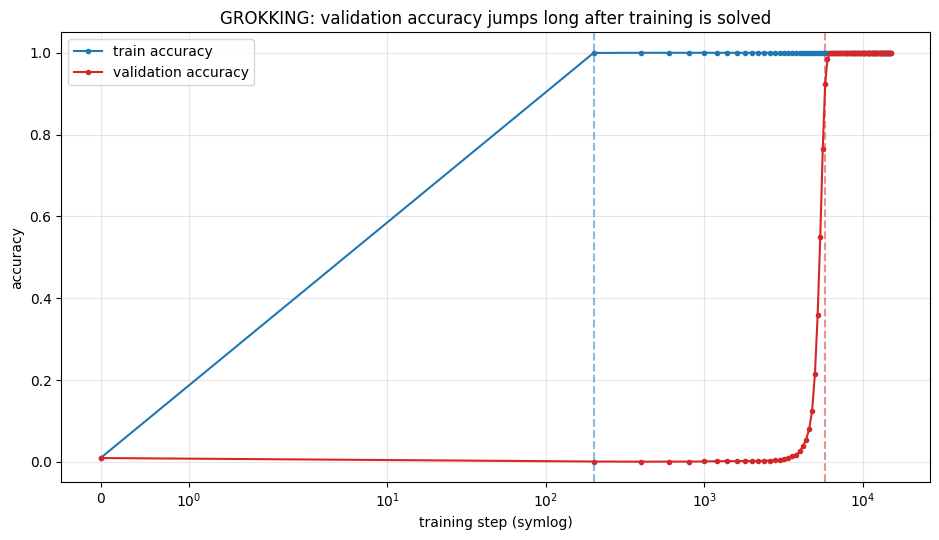

train reached ~100% at step 200
validation 'grokked' (>90%) at step 5800  --> a 29x delay after memorization


In [2]:
g = grok
fig, ax = plt.subplots(figsize=(9.5, 5.5))
ax.plot(g["step"], g["train"], "-o", ms=3, color="tab:blue", label="train accuracy")
ax.plot(g["step"], g["val"], "-o", ms=3, color="tab:red", label="validation accuracy")
ax.set_xscale("symlog"); ax.set_title("GROKKING: validation accuracy jumps long after training is solved")
ax.set_xlabel("training step (symlog)"); ax.set_ylabel("accuracy"); ax.legend(); ax.grid(alpha=0.3, which="both")
# annotate the two moments
tr_solved = next(s for s,a in zip(g["step"],g["train"]) if a>0.99)
val_grok = next((s for s,a in zip(g["step"],g["val"]) if a>0.9), None)
ax.axvline(tr_solved, ls="--", color="tab:blue", alpha=0.5)
if val_grok: ax.axvline(val_grok, ls="--", color="tab:red", alpha=0.5)
plt.tight_layout(); plt.show()
print(f"train reached ~100% at step {tr_solved}")
print(f"validation 'grokked' (>90%) at step {val_grok}  --> a {val_grok//max(tr_solved,1)}x delay after memorization")
assert val_grok is not None, "validation never reached 90% - grokking did not reproduce"
assert val_grok > 10 * tr_solved, \
    f"no delayed generalization: memorized at step {tr_solved}, grokked at step {val_grok}"


**What to notice.** This is the reproduction. **Training accuracy hits ~100% almost immediately** (the model memorizes the training pairs), while **validation accuracy sits at near-zero for thousands of steps** — the model looks hopelessly overfit. Then, with no change in procedure, validation accuracy **suddenly leaps to ~100%**: the network *grokked* the actual modular-addition rule, long after it had "given up" looking like it was learning. This delayed, phase-transition-like generalization is genuinely surprising — it violates the intuition that val performance tracks train performance — and we reproduced it from scratch in a couple of minutes. That "aha, it really happens" is the payoff of reproduction.


## 4. Ablate: is weight decay really essential? (step 5)

The paper claims weight decay is crucial. We already trained an identical model with `weight_decay=0`. Let's overlay the two validation curves to test that claim directly — the heart of a good reproduction is *checking the mechanism*, not just the headline.


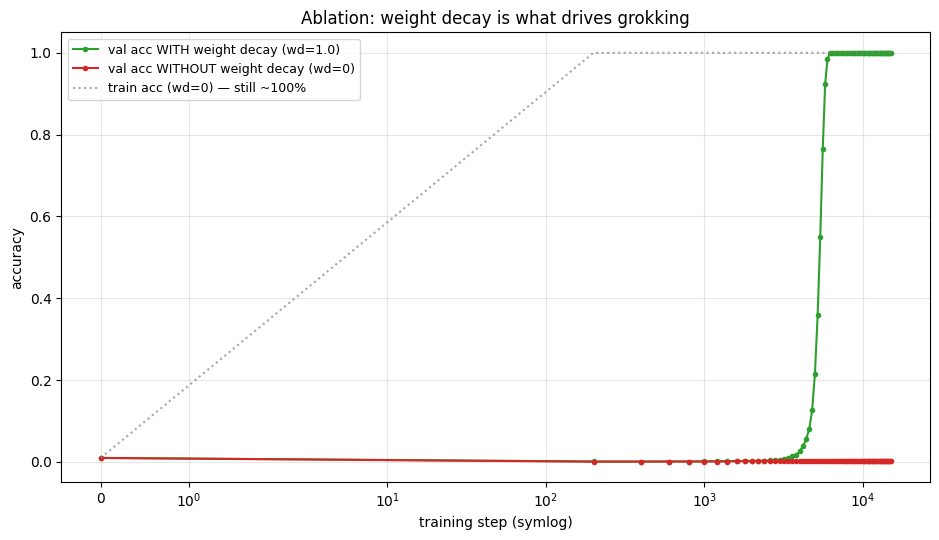

final val acc — with weight decay: 1.000  |  without: 0.001


In [3]:
fig, ax = plt.subplots(figsize=(9.5, 5.5))
ax.plot(grok["step"], grok["val"], "-o", ms=3, color="tab:green", label="val acc WITH weight decay (wd=1.0)")
ax.plot(noreg["step"], noreg["val"], "-o", ms=3, color="tab:red", label="val acc WITHOUT weight decay (wd=0)")
ax.plot(noreg["step"], noreg["train"], ":", color="gray", alpha=0.7, label="train acc (wd=0) — still ~100%")
ax.set_xscale("symlog"); ax.set_title("Ablation: weight decay is what drives grokking")
ax.set_xlabel("training step (symlog)"); ax.set_ylabel("accuracy"); ax.legend(fontsize=9); ax.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()
print(f"final val acc — with weight decay: {grok['val'][-1]:.3f}  |  without: {noreg['val'][-1]:.3f}")
assert grok["val"][-1] > 0.9 > noreg["val"][-1], (
    f"ablation failed: wd=1.0 reached {grok['val'][-1]:.3f} and wd=0 reached "
    f"{noreg['val'][-1]:.3f} - weight decay should be what separates them")


**What to notice.** With weight decay (green), validation groks to ~100%. **Without** weight decay (red), the model still memorizes (gray train curve ~100%) but validation stays far lower within the same budget — grokking is dramatically slower or absent. This **confirms the paper's mechanistic claim**: weight decay is a key driver. The interpretation (from follow-up work): weight decay pressures the network away from the high-norm *memorizing* solution toward a lower-norm *generalizing* solution (the clean, periodic "Fourier" circuits that actually compute modular addition) — memorization is easy to find first, but regularization eventually pushes the model to the simpler rule. Ablation is where you learn *why*, not just *that*.


## 5. Write it up (step 6)

**Reproduction report — Grokking (Power et al. 2022):**
- ✅ **Reproduced the core claim.** On $(a+b)\bmod 97$ with a 50/50 split, an MLP reaches 100% train accuracy almost immediately, then validation accuracy jumps from ~0% to ~100% *thousands of steps later* — the delayed, sudden generalization ("grokking").
- ✅ **Reproduced the weight-decay claim.** Removing weight decay drastically slows/removes grokking, confirming it as a key driver.
- 🔍 **Finding beyond the paper's headline:** the effect reproduces with a simple **MLP** (not just a transformer) — the phenomenon is about the *task + regularization*, not a specific architecture.
- 📌 **What it means:** generalization and memorization are *distinct* solutions the optimizer can find at different times; a model can be secretly "learning" while looking fully overfit. This complicates naive early-stopping and is an active area (mechanistic interpretability has since reverse-engineered the grokked circuits).

That's a complete reproduction: claim → minimal setup → run → compare → ablate → interpret. Repeat this for any paper.

## 6. Exercises
1. **Data fraction.** Sweep the train fraction (30%, 40%, 60%, 80%). How does the grokking delay change? (Less data → later grokking, up to a threshold below which it never groks.)
2. **Other operations.** Try $(a-b)\bmod p$, $a\cdot b \bmod p$, or $a^2+b^2 \bmod p$. Which grok? Which don't?
3. **Weight-decay strength.** Sweep wd ∈ {0, 0.1, 0.5, 1, 3}; plot grokking step vs wd.
4. **Mechanistic peek.** After grokking, inspect the embedding matrix with an FFT — do you see the periodic (Fourier) structure that implements modular addition?
5. **Transformer version.** Reproduce with a 1-layer transformer (the paper's model); compare the grokking dynamics.
6. **Track weight norm.** Plot the model's weight norm over training; correlate its drop with the grokking moment.

## 7. Interview / residency framing
- *"Walk me through reproducing a paper."* → claim → minimal setup → implement → run & compare to their figure → ablate to find the essential ingredient → write up matches/mismatches.
- *"What is grokking?"* → sudden generalization long after perfect memorization on small algorithmic tasks; val accuracy phase-transitions up thousands of steps after train saturates.
- *"What drives it?"* → weight decay (regularization) pushing the model from a high-norm memorizing solution to a low-norm generalizing one; verifiable by ablation.
- *"Why does grokking matter?"* → memorization and generalization are distinct optimizer basins; challenges "val tracks train" intuition and naive early stopping; a testbed for mechanistic interpretability.
- *"How would you debug a non-reproducing result?"* → check the exact hyperparameters (they matter a lot here — wd, LR, data fraction), minimize the setup, and ablate one thing at a time.

## 📚 References & papers

This notebook reproduces / builds on:

- **Grokking: Generalization Beyond Overfitting on Small Algorithmic Datasets** — Power, Burda, Edwards, Babuschkin & Misra (2022), arXiv:2201.02177. The reproduced paper.
- **Progress measures for grokking via mechanistic interpretability** — Nanda et al. (2023), arXiv:2301.05217. Reverse-engineers the grokked Fourier circuits.
- **Towards Understanding Grokking (Omnigrok)** — Liu et al. (2022), arXiv:2210.01117. The weight-norm / representation view.

---
**Next:** *Tier 6 · Notebook 28 — Reproducing Deep Double Descent*: the test-error curve that goes down, up, then down again as models grow past the interpolation threshold — overturning classical bias-variance intuition.
